   Severity           Start_Time State  Temperature(F) Weather_Condition  \
0         3  2016-02-08 05:46:00    OH            36.9        Light Rain   
1         2  2016-02-08 06:07:59    OH            37.9        Light Rain   
2         2  2016-02-08 06:49:27    OH            36.0          Overcast   
3         3  2016-02-08 07:23:34    OH            35.1     Mostly Cloudy   
4         2  2016-02-08 07:39:07    OH            36.0     Mostly Cloudy   

   Junction  
0     False  
1     False  
2     False  
3     False  
4     False  
<class 'pandas.DataFrame'>
RangeIndex: 4680800 entries, 0 to 4680799
Data columns (total 6 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Severity           int64  
 1   Start_Time         str    
 2   State              str    
 3   Temperature(F)     float64
 4   Weather_Condition  str    
 5   Junction           bool   
dtypes: bool(1), float64(1), int64(1), str(3)
memory usage: 183.0 MB
None


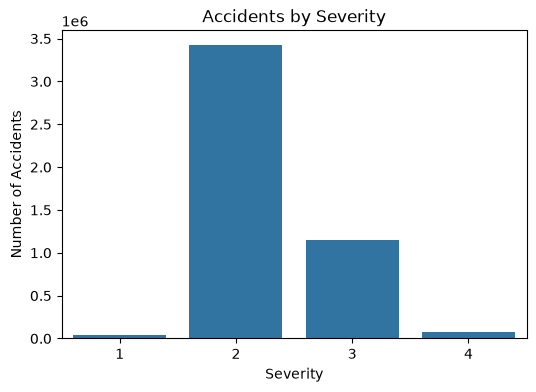

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("US_Accidents_Small.csv")

print(df.head())
print(df.info())

df = df[[
    "Severity",
    "Weather_Condition",
    "Temperature(F)",
    "Start_Time",
    "Junction",
    "State"
]]

df = df.dropna()

df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="ISO8601")
df["Hour"] = df["Start_Time"].dt.hour

plt.figure(figsize=(6,4))
sns.countplot(x="Severity", data=df)
plt.title("Accidents by Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(
    y="Weather_Condition",
    data=df,
    order=df["Weather_Condition"].value_counts().head(10).index
)
plt.title("Top 10 Weather Conditions")
plt.xlabel("Number of Accidents")
plt.ylabel("Weather Condition")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["Temperature(F)"], bins=20, kde=True)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (F)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(x="Hour", data=df)
plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Junction", data=df)
plt.title("Accidents Near Junctions")
plt.xlabel("Junction")
plt.ylabel("Number of Accidents")
plt.show()

plt.figure(figsize=(10,6))
sns.countplot(
    y="State",
    data=df,
    order=df["State"].value_counts().head(10).index
)
plt.title("Top 10 Accident Hotspot States")
plt.xlabel("Number of Accidents")
plt.ylabel("State")
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()